### Using UCC to improve performance on FakeTorino


In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit_aer import AerSimulator

# 1. Initialize the fake backend
fake_backend = FakeTorino()

In [14]:
%matplotlib inline

In [15]:
# from ucc.tests.test_compile import random_clifford_circuit


In [16]:
import ucc


# 2. Create a quantum circuit
def bell_state_circuit(num_qubits=2):
    qc = QuantumCircuit(num_qubits, num_qubits)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc


results = []
for compiler in [ucc.compile, transpile]:
    qc = bell_state_circuit(10)

    # 3. Transpile the circuit for the fake backend
    # This adapts the circuit to the backend's specific architecture and basis gates.
    if compiler == ucc.compile:
        transpiled_qc = ucc.compile(qc, target_device=fake_backend.target)
    else:
        # Use the transpile function from Qiskit if not using UCC

        transpiled_qc = transpile(qc, fake_backend)

    # 4. Create an AerSimulator with the noise model of the fake backend
    # This allows for noisy simulation mimicking the real hardware.
    simulator = AerSimulator.from_backend(fake_backend)

    # 5. Run the transpiled circuit on the simulator
    job = simulator.run(transpiled_qc, shots=5000)
    result = job.result()
    counts = result.get_counts(transpiled_qc)
    results.append((compiler.__name__, counts))

    # 6. Print the results
    print(
        f"Counts from noisy simulation on FakeTorino with {compiler.__name__}: {counts}"
    )

/Users/jordansullivan/UnitaryFund/ucc/ucc/compile.py:73: UserWarning: Warning: The target gateset None is not supported by the target device. 
  warnings.warn(


Counts from noisy simulation on FakeTorino with compile: {'0000000001': 74, '0000000010': 89, '0000000011': 2392, '0000000000': 2445}
Counts from noisy simulation on FakeTorino with transpile: {'0000000001': 50, '0000000010': 57, '0000000000': 2451, '0000000011': 2442}


In [17]:
import matplotlib.pyplot as plt

print(results)

[('compile', {'0000000001': 74, '0000000010': 89, '0000000011': 2392, '0000000000': 2445}), ('transpile', {'0000000001': 50, '0000000010': 57, '0000000000': 2451, '0000000011': 2442})]


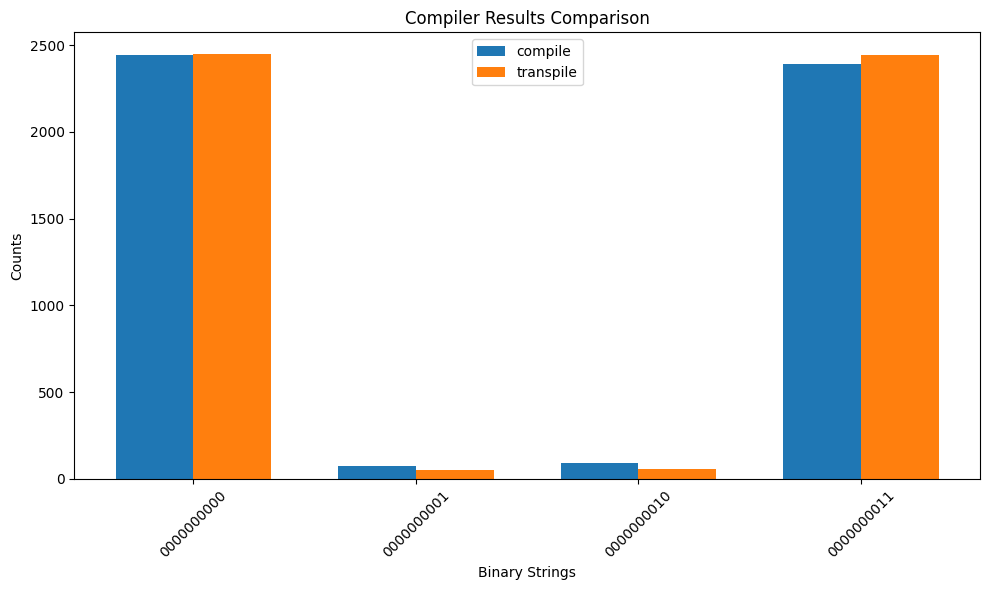

In [ ]:
import numpy as np

# Your data
data = results
# Extract binary strings (keys) and sort them
binary_strings = sorted(data[0][1].keys())
compilers = [item[0] for item in data]

# Prepare data for plotting
values = []
for compiler, counts in data:
    values.append([counts[b] for b in binary_strings])

# Set up the plot
x = np.arange(len(binary_strings))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for each compiler
for i, (compiler, compiler_values) in enumerate(zip(compilers, values)):
    offset = width * i
    ax.bar(x + offset, compiler_values, width, label=compiler)

# Customize the plot
ax.set_xlabel("Bitstrings")
ax.set_ylabel("Counts")
ax.set_title("Compiler Results Comparison")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(binary_strings, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()